In [4]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
tickers = [
    "MSFT", "NVDA", "AAPL", "AMZN", "META", "AVGO", "GOOGL", "TSLA", "BRK-B", "GOOG",
    "JPM", "V", "LLY", "NFLX", "MA", "COST", "XOM", "WMT", "PG", "JNJ",
    "HD", "ABBV", "BAC", "UNH", "KO", "PM", "CRM", "ORCL", "CSCO", "GE",
    "PLTR", "IBM", "WFC", "ABT", "MCD", "CVX", "LIN", "NOW", "DIS", "ACN",
    "T", "ISRG", "MRK", "UBER", "GS", "INTU", "VZ", "AMD", "ADBE", "RTX",
    "PEP", "BKNG", "TXN", "QCOM", "PGR", "CAT", "SPGI", "AXP", "MS", "BSX",
    "BA", "TMO", "SCHW", "TJX", "NEE", "AMGN", "HON", "C", "UNP",
    "GILD", "CMCSA", "AMAT", "ADP", "PFE", "SYK", "DE", "LOW", "ETN", "GEV",
    "PANW", "DHR", "COF", "TMUS", "VRTX", "COP", "ADI", "MDT", "CB",
    "CRWD", "MU", "LRCX", "APH", "KLAC", "CME", "MO", "BX", "ICE", "AMT"
]

In [17]:
df = yf.download(
    tickers = tickers,
    start = "2018-01-01", 
    end = "2025-12-31",
    interval = "1d",
    group_by = 'ticker',
    auto_adjust = True,
    threads = True,
)
df = df.stack(level = 0, future_stack = True).reset_index()
df.rename(columns={'level_1': 'Ticker'}, inplace=True)
df = df.sort_values(['Ticker', 'Date'])
df['Target'] = df.groupby('Ticker')['Close'].shift(-1) > df['Close']
df['Target'] = df['Target'].astype(int)
df = df.dropna()

[*********************100%***********************]  98 of 98 completed


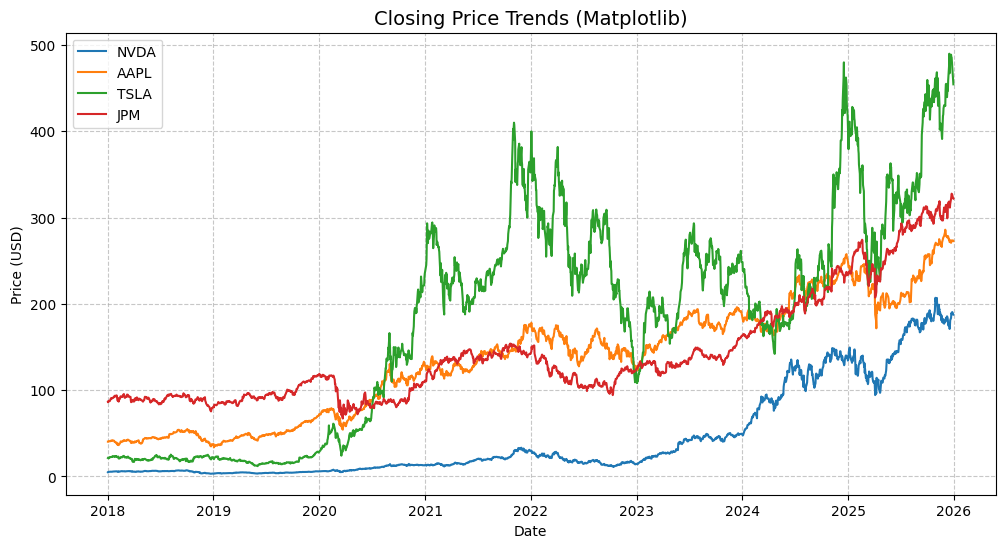

In [18]:
# Pick 3-4 diverse tickers
sample_tickers = ['NVDA', 'AAPL', 'TSLA', 'JPM']

plt.figure(figsize=(12, 6))
for ticker in sample_tickers:
    subset = df[df['Ticker'] == ticker]
    plt.plot(subset['Date'], subset['Close'], label=ticker)

plt.title('Closing Price Trends (Matplotlib)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

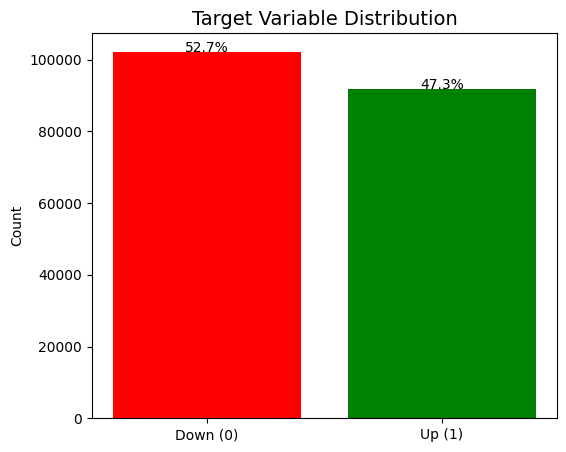

In [20]:
counts = df['Target'].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(['Down (0)', 'Up (1)'], counts.values, color=['red', 'green'])
plt.title('Target Variable Distribution', fontsize=14)
plt.ylabel('Count')

# Add percentage labels on top of bars
for i, val in enumerate(counts.values):
    plt.text(i, val + 5, f'{(val/len(df)*100):.1f}%', ha='center')

plt.show()

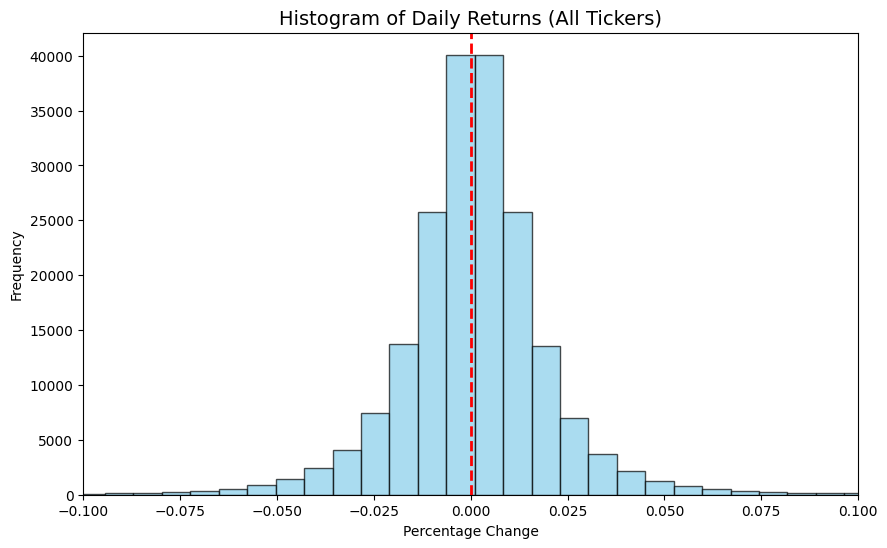

In [21]:
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

plt.figure(figsize=(10, 6))
plt.hist(df['Daily_Return'].dropna(), bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='dashed', linewidth=2) # Neutral line
plt.title('Histogram of Daily Returns (All Tickers)', fontsize=14)
plt.xlabel('Percentage Change')
plt.ylabel('Frequency')
plt.xlim(-0.1, 0.1) # Crop outliers for better visibility
plt.show()

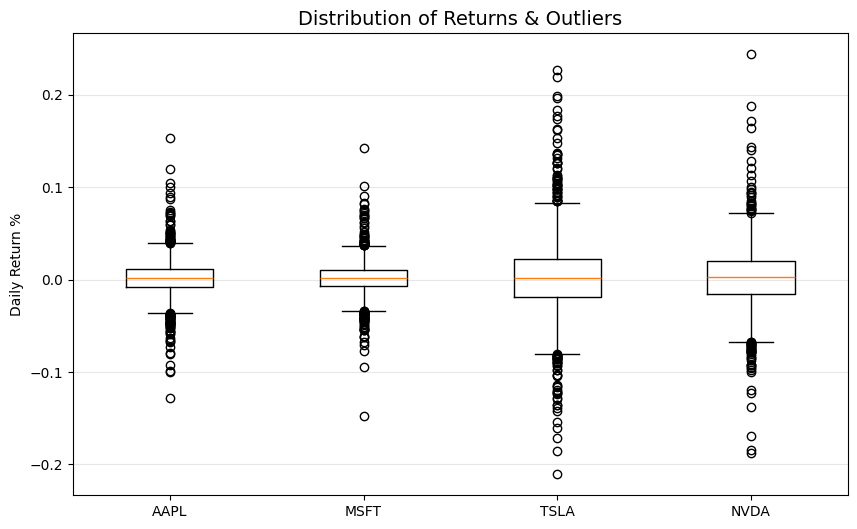

In [25]:
# Create a boxplot for returns of a few top stocks
tickers_to_compare = ['AAPL', 'MSFT', 'TSLA', 'NVDA']
data_to_plot = [df[df['Ticker'] == t]['Daily_Return'].dropna() for t in tickers_to_compare]

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, tick_labels=tickers_to_compare)
plt.title('Distribution of Returns & Outliers', fontsize=14)
plt.ylabel('Daily Return %')
plt.grid(axis='y', alpha=0.3)
plt.show()

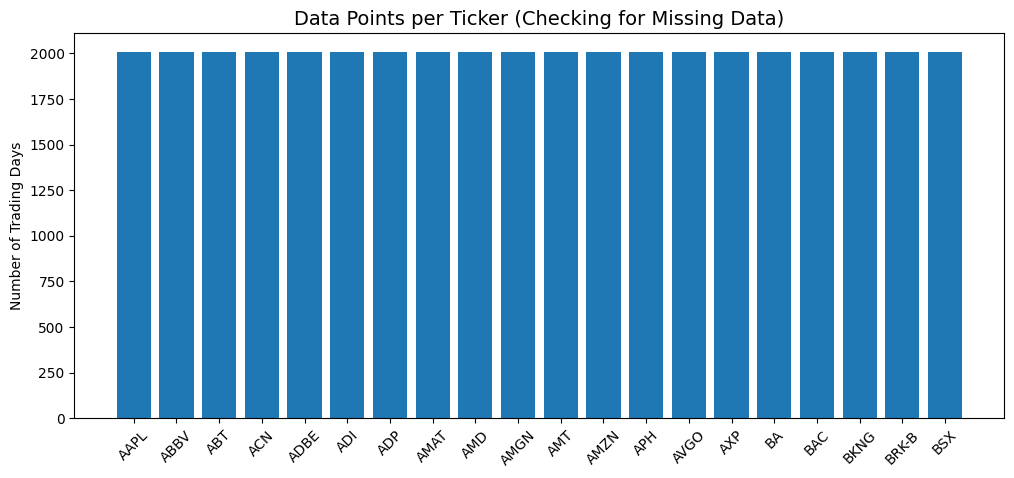

In [26]:
ticker_counts = df['Ticker'].value_counts()

plt.figure(figsize=(12, 5))
plt.bar(ticker_counts.index[:20], ticker_counts.values[:20]) # Top 20 for clarity
plt.xticks(rotation=45)
plt.title('Data Points per Ticker (Checking for Missing Data)', fontsize=14)
plt.ylabel('Number of Trading Days')
plt.show()